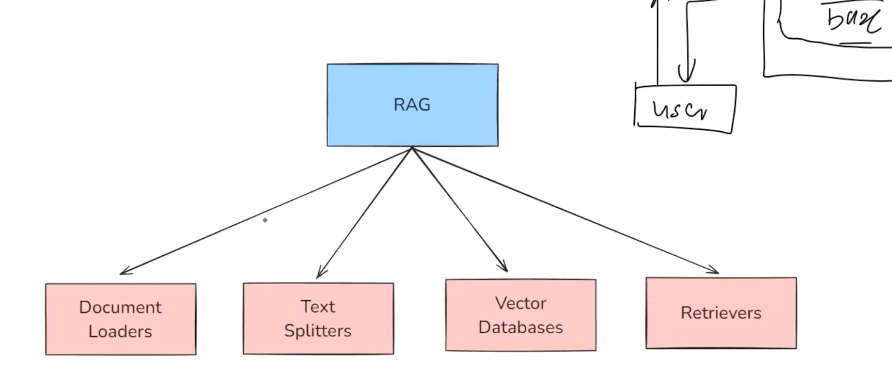

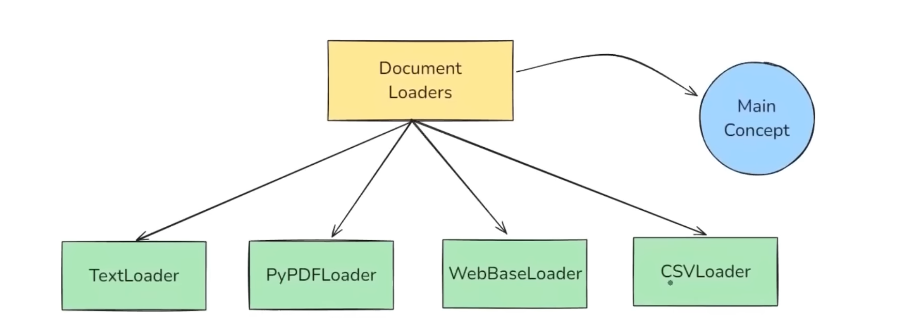

# Document Loaders in LangChain


Document loaders are **components in LangChain** used to load data from various sources into a standardized format (usually as **Document objects**), which can then be used for chunking, embedding, retrieval, and generation.

## Document

```python
Document(
    page_content="The actual text content",
    metadata={"source": "filename.pdf", ...}
)

# TextLoader


TextLoader is a simple and commonly used document loader in LangChain that reads plain text (`.txt`) files and converts them into LangChain Document objects.

## Use Case

* Ideal for loading chat logs, scraped text, transcripts, code snippets, or any plain text data into a LangChain pipeline.

## Limitation

* Works only with `.txt` files.

## Working

```text
.txt file ──> Document object
```

A document loader reads the text file and converts its content into a **Document object** that can be used in a LangChain pipeline.


In [1]:
from langchain_community.document_loaders import TextLoader

In [8]:
loader = TextLoader(file_path='cricket.txt',encoding='utf-8')

In [9]:
docs = loader.load()

In [10]:
type(docs)

list

In [12]:
docs

[Document(metadata={'source': 'cricket.txt'}, page_content='Beneath the sun or floodlight\'s gleam,\n\nCricket lives like a waking dream.\n\nA field of green, a willowed sound,\n\nWhere legends rise and tales are found.\n\nFrom dusty lanes where barefoot boys,\n\nChase every run with shrieks of joy,\n\nTo packed arenas roaring loud,\n\nThe game unites a global crowd.\n\nA coin is tossed, the captains stare,\n\nAs tension thickens in the air.\n\nBat or bowl? A choice so bold,\n\nA story new begins, retold.\n\nThe openers walk, calm yet brave,\n\nEach stride a wave upon the wave.\n\nThey face the ball with narrowed eyes,\n\nAs silence grips the watching skies.\n\nThe bowler runs, a rhythmic beat,\n\nLike thunder galloping on feet.\n\nA leather flash, a wooden crack—\n\nThe ball takes flight, then tumbles back.\n\nA flick through square, a drive through mid,\n\nA lofted shot the fielder missed.\n\nA single, double, sprint for three,\n\nThe crowd erupts in ecstasy.\n\nBut not for long—the 

In [13]:
docs[0]

Document(metadata={'source': 'cricket.txt'}, page_content='Beneath the sun or floodlight\'s gleam,\n\nCricket lives like a waking dream.\n\nA field of green, a willowed sound,\n\nWhere legends rise and tales are found.\n\nFrom dusty lanes where barefoot boys,\n\nChase every run with shrieks of joy,\n\nTo packed arenas roaring loud,\n\nThe game unites a global crowd.\n\nA coin is tossed, the captains stare,\n\nAs tension thickens in the air.\n\nBat or bowl? A choice so bold,\n\nA story new begins, retold.\n\nThe openers walk, calm yet brave,\n\nEach stride a wave upon the wave.\n\nThey face the ball with narrowed eyes,\n\nAs silence grips the watching skies.\n\nThe bowler runs, a rhythmic beat,\n\nLike thunder galloping on feet.\n\nA leather flash, a wooden crack—\n\nThe ball takes flight, then tumbles back.\n\nA flick through square, a drive through mid,\n\nA lofted shot the fielder missed.\n\nA single, double, sprint for three,\n\nThe crowd erupts in ecstasy.\n\nBut not for long—the t

In [14]:
docs[0].page_content

'Beneath the sun or floodlight\'s gleam,\n\nCricket lives like a waking dream.\n\nA field of green, a willowed sound,\n\nWhere legends rise and tales are found.\n\nFrom dusty lanes where barefoot boys,\n\nChase every run with shrieks of joy,\n\nTo packed arenas roaring loud,\n\nThe game unites a global crowd.\n\nA coin is tossed, the captains stare,\n\nAs tension thickens in the air.\n\nBat or bowl? A choice so bold,\n\nA story new begins, retold.\n\nThe openers walk, calm yet brave,\n\nEach stride a wave upon the wave.\n\nThey face the ball with narrowed eyes,\n\nAs silence grips the watching skies.\n\nThe bowler runs, a rhythmic beat,\n\nLike thunder galloping on feet.\n\nA leather flash, a wooden crack—\n\nThe ball takes flight, then tumbles back.\n\nA flick through square, a drive through mid,\n\nA lofted shot the fielder missed.\n\nA single, double, sprint for three,\n\nThe crowd erupts in ecstasy.\n\nBut not for long—the trap is set,\n\nThe spinner loops, the pitch is wet.\n\nA s

In [15]:
docs[0].metadata

{'source': 'cricket.txt'}

# PyPDFLoader


PyPDFLoader is a document loader in LangChain used to load content from PDF files and convert each page into a Document object.

## Working

```text
PDF
 ↓
PyPDFLoader
 ↓
Multiple Document objects
```

For example, if a PDF has **25 pages**, PyPDFLoader creates **25 Document objects** — one for each page.

```python
[
    Document(page_content="Text from page 1", metadata={"page": 0, "source": "file.pdf"}),
    Document(page_content="Text from page 2", metadata={"page": 1, "source": "file.pdf"}),
    ...
]
```

## Limitation

* It uses the **PyPDF** library under the hood.
* Not great with **scanned PDFs** or **complex layouts**.

## Use Case → Recommended Loader

| Use Case                       | Recommended Loader                                   |
| ------------------------------ | ---------------------------------------------------- |
| Simple, clean PDFs             | `PyPDFLoader`                                        |
| PDFs with tables/columns       | `PDFPlumberLoader`                                   |
| Scanned/Image PDFs             | `UnstructuredPDFLoader` or `AmazonTextractPDFLoader` |
| Need layout and image data     | `PyMuPDFLoader`                                      |
| Want best structure extraction | `UnstructuredPDFLoader`                              |


In [16]:
from langchain_community.document_loaders import PyPDFLoader

In [17]:
loader = PyPDFLoader(file_path='dl-curriculum.pdf')

In [19]:
docs = loader.load()

In [20]:
len(docs)

23

In [22]:
docs[0].page_content

'CampusX\nDeep\nLearning\nCurriculum\nA.\nArtificial\nNeural\nNetwork\nand\nhow\nto\nimprove\nthem\n1.\nBiological\nInspiration\n●\nUnderstanding\nthe\nneuron\nstructure\n●\nSynapses\nand\nsignal\ntransmission\n●\nHow\nbiological\nconcepts\ntranslate\nto\nartificial\nneurons\n2.\nHistory\nof\nNeural\nNetworks\n●\nEarly\nmodels\n(Perceptron)\n●\nBackpropagation\nand\nMLPs\n●\nThe\n"AI\nWinter"\nand\nresurgence\nof\nneural\nnetworks\n●\nEmergence\nof\ndeep\nlearning\n3.\nPerceptron\nand\nMultilayer\nPerceptrons\n(MLP)\n●\nSingle-layer\nperceptron\nlimitations\n●\nXOR\nproblem\nand\nthe\nneed\nfor\nhidden\nlayers\n●\nMLP\narchitecture\n4.\nLayers\nand\nTheir\nFunctions\n●\nInput\nLayer\n○\nAccepting\ninput\ndata\n●\nHidden\nLayers\n○\nFeature\nextraction\n●\nOutput\nLayer\n○\nProducing\nfinal\npredictions\n5.\nActivation\nFunctions'

In [23]:
docs[0].metadata

{'producer': 'Skia/PDF m131 Google Docs Renderer',
 'creator': 'PyPDF',
 'creationdate': '',
 'title': 'Deep Learning Curriculum',
 'source': 'dl-curriculum.pdf',
 'total_pages': 23,
 'page': 0,
 'page_label': '1'}

# DirectoryLoader



DirectoryLoader is a document loader that lets you load **multiple documents from a directory (folder) of files**.

## Working

```text
Directory / Folder
│
├── file1.txt
├── file2.pdf
├── file3.txt
├── file4.pdf
└── ...
        ↓
DirectoryLoader
        ↓
LangChain Documents
```

## Glob Pattern

| Glob Pattern   | What It Loads                          |
| -------------- | -------------------------------------- |
| `"**/*.txt"`   | All `.txt` files in all subfolders     |
| `"*.pdf"`      | All `.pdf` files in the root directory |
| `"data/*.csv"` | All `.csv` files in the `data/` folder |
| `"**/*"`       | All files (any type, all folders)      |

> `**` = recursive search through subfolders.

## Example

```python
from langchain_community.document_loaders import DirectoryLoader

loader = DirectoryLoader(
    "data/",
    glob="**/*.txt"
)

documents = loader.load()
```

This loads all `.txt` files from the `data/` directory and its subdirectories into LangChain `Document` objects.


In [24]:
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader

In [25]:
loader = DirectoryLoader(path ='books',glob='*.pdf',loader_cls=PyPDFLoader)

In [26]:
docs = loader.load()

In [27]:
len(docs)

326

In [28]:
docs[0].page_content

'[ 1 ]'

In [29]:
docs[0].metadata

{'producer': 'Adobe PDF Library 10.0.1',
 'creator': 'Adobe InDesign CS6 (Windows)',
 'creationdate': '2015-03-24T13:14:02+05:30',
 'moddate': '2015-03-25T17:33:08+05:30',
 'trapped': '/False',
 'source': 'books\\Building Machine Learning Systems with Python - Second Edition.pdf',
 'total_pages': 326,
 'page': 0,
 'page_label': 'Cover'}

# Load vs Lazy Load


## `load()`

* **Eager Loading** — loads everything at once.
* Returns a **list of `Document` objects**.
* Loads all documents immediately into memory.

### Best when:

* The number of documents is **small**.
* You want everything **loaded upfront**.

---

## `lazy_load()`

* **Lazy Loading** — loads documents on demand.
* Returns a **generator of `Document` objects**.
* Documents are **not all loaded at once**; they are fetched one at a time as needed.

### Best when:

* You're dealing with **large documents or lots of files**.
* You want to **stream processing** (e.g., chunking, embedding) without using lots of memory.

## Key Difference

```text
load()
   ↓
All documents loaded at once
   ↓
List of Document objects


lazy_load()
   ↓
Documents loaded one at a time
   ↓
Generator of Document objects
```

**Simple rule:**

> Use `load()` for small datasets and `lazy_load()` when you want memory-efficient processing of large datasets.


# WebBaseLoader



WebBaseLoader is a document loader in LangChain used to **load and extract text content from web pages (URLs)**.

It uses **BeautifulSoup** under the hood to parse HTML and extract visible text.

## When to Use

- For blogs, news articles, or public websites where the content is primarily **text-based and static**.

## Limitations

- Doesn't handle **JavaScript-heavy pages** well (use `SeleniumURLLoader` for that).
- Loads only static content (what's in the HTML, **not what loads after the page renders**).

# CSVLoader


CSVLoader is a document loader in LangChain used to **load data from CSV (Comma-Separated Values) files** and convert each row into a LangChain `Document` object.

It is useful when you have structured data stored in a CSV file and want to process it using LangChain.

## When to Use

- For loading **CSV files** containing structured or tabular data.
- Useful for datasets such as **customer records, product information, employee data, or other tabular data**.
- Each row can be converted into a separate `Document` object.

## Working

```text
CSV File
   ↓
CSVLoader
   ↓
Document Objects